# Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set plotting style for professional appearance
plt.style.use('seaborn-v0_8-muted')

# Loading and Inspecting the Data

In [2]:
# Load the dataset while skipping the metadata rows
file_path = "D:\Projects for PORT\GDP\Egypt GDP from 2014 - 2024.csv"
df_raw = pd.read_csv(file_path, skiprows=6)

# Display the first few rows and structure
print("--- Dataset Head ---")
print(df_raw.head())

print("\n--- Dataset Info ---")
print(df_raw.info())

--- Dataset Head ---
  Country Name Country Code     Indicator Name  Indicator Code          2014  \
0        Egypt          EGY  GDP (current US$)  NY.GDP.MKTP.CD  3.055950e+11   

           2015          2016          2017          2018          2019  \
0  3.293670e+11  3.324420e+11  2.483630e+11  2.625890e+11  3.186790e+11   

           2020          2021          2022          2023          2024  
0  3.838180e+11  4.246720e+11  4.767480e+11  3.959260e+11  3.890600e+11  

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    1 non-null      object 
 1   Country Code    1 non-null      object 
 2   Indicator Name  1 non-null      object 
 3   Indicator Code  1 non-null      object 
 4   2014            1 non-null      float64
 5   2015            1 non-null      float64
 6   2016            1 non-null     

Insight: The dataset represents the total market value of all final goods and services produced within Egypt, expressed in current US Dollars. This metric is highly sensitive to the exchange rate of the Egyptian Pound (EGP) against the USD.

# Data Transformation (Reshaping & Cleaning)

In [3]:
# Reshape from Wide to Long format
year_columns = [str(year) for year in range(2014, 2025)]
df_melted = df_raw.melt(id_vars=['Country Name'], value_vars=year_columns, 
                        var_name='Year', value_name='GDP_Raw')

# Convert Year to integer and GDP to Billion USD
df_melted['Year'] = df_melted['Year'].astype(int)
df_melted['GDP_Billion_USD'] = df_melted['GDP_Raw'] / 1e9

# Calculate Year-over-Year (YoY) Growth Rate (%)
df_melted['Growth_Rate'] = df_melted['GDP_Billion_USD'].pct_change() * 100

# Select relevant columns for the final clean dataframe
df_final = df_melted[['Year', 'GDP_Billion_USD', 'Growth_Rate']].copy()
print(df_final)

    Year  GDP_Billion_USD  Growth_Rate
0   2014          305.595          NaN
1   2015          329.367     7.778923
2   2016          332.442     0.933609
3   2017          248.363   -25.291329
4   2018          262.589     5.727906
5   2019          318.679    21.360377
6   2020          383.818    20.440318
7   2021          424.672    10.644107
8   2022          476.748    12.262640
9   2023          395.926   -16.952772
10  2024          389.060    -1.734162


# Visualizing GDP Trends

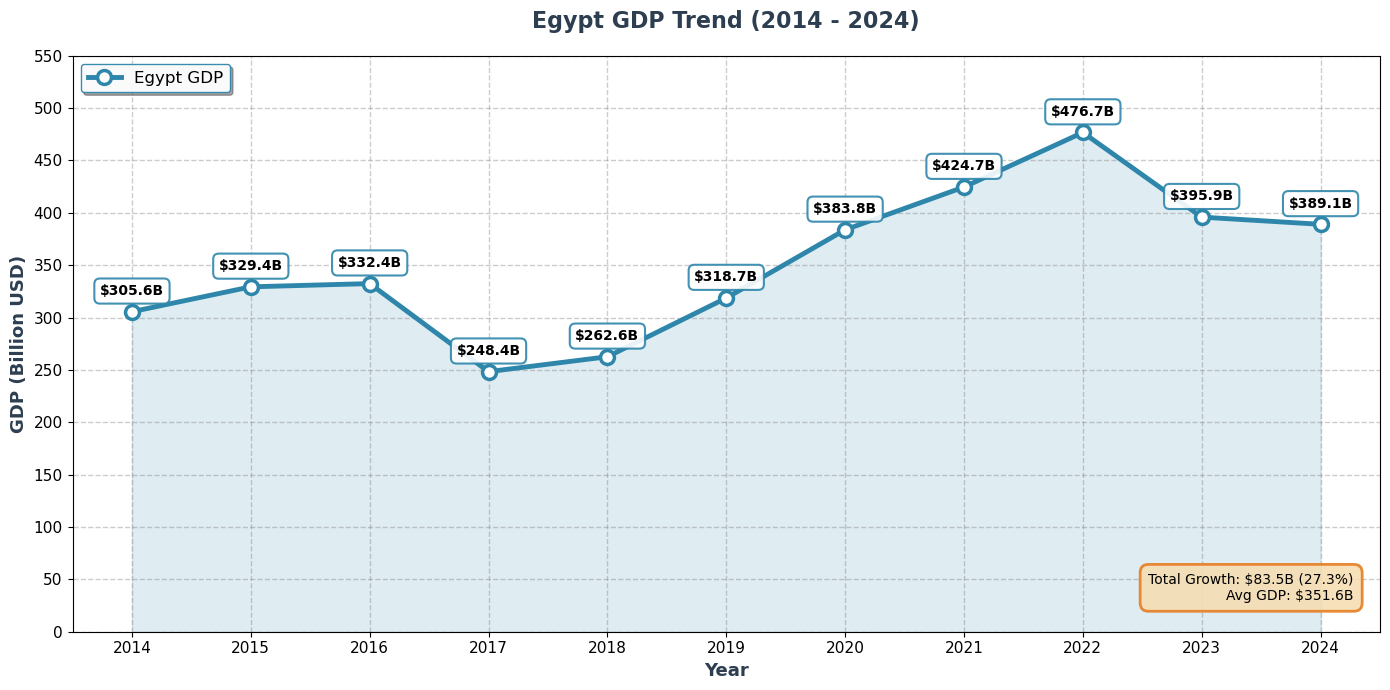

In [16]:
# Enhanced version of your existing GDP visualization
# Professional improvements while keeping your original structure

import matplotlib.pyplot as plt
import numpy as np

# Create figure with better resolution and size
plt.figure(figsize=(14, 7), facecolor='white', dpi=100)

# Plot the main line with enhanced styling
plt.plot(df_final['Year'], df_final['GDP_Billion_USD'], 
         marker='o', color='#2E86AB', linewidth=3.5, markersize=10,
         markerfacecolor='white', markeredgewidth=2.5, markeredgecolor='#2E86AB',
         label='Egypt GDP', zorder=3)

# Add value labels on each point for better readability
for idx, row in df_final.iterrows():
    plt.annotate(f'${row["GDP_Billion_USD"]:.1f}B',
                xy=(row['Year'], row['GDP_Billion_USD']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                         edgecolor='#2E86AB', alpha=0.9, linewidth=1.5))

# Add a subtle gradient fill under the line
plt.fill_between(df_final['Year'], 0, df_final['GDP_Billion_USD'], 
                 alpha=0.15, color='#2E86AB', zorder=1)

# Keep your Y-axis settings
max_val = df_final['GDP_Billion_USD'].max()
upper_limit = int(np.ceil(max_val / 50) * 50) + 50 
plt.ylim(0, upper_limit)
plt.yticks(np.arange(0, upper_limit + 1, 50))

# Enhanced title and labels with better formatting
plt.title('Egypt GDP Trend (2014 - 2024)', 
         fontsize=16, fontweight='bold', pad=20, color='#2C3E50')
plt.ylabel('GDP (Billion USD)', fontsize=13, fontweight='bold', color='#2C3E50')
plt.xlabel('Year', fontsize=13, fontweight='bold', color='#2C3E50')

# Enhanced grid
plt.grid(True, linestyle='--', alpha=0.4, linewidth=1, color='gray', zorder=0)

# Keep your X-axis ticks
plt.xticks(df_final['Year'], fontsize=11)
plt.yticks(fontsize=11)

# Add legend
plt.legend(loc='upper left', fontsize=12, framealpha=0.95, 
          edgecolor='#2E86AB', fancybox=True, shadow=True)

# Add a statistics box in the corner
total_growth = df_final['GDP_Billion_USD'].iloc[-1] - df_final['GDP_Billion_USD'].iloc[0]
pct_growth = (total_growth / df_final['GDP_Billion_USD'].iloc[0]) * 100
stats_text = f'Total Growth: ${total_growth:.1f}B ({pct_growth:.1f}%)\n'
stats_text += f'Avg GDP: ${df_final["GDP_Billion_USD"].mean():.1f}B'

plt.text(0.98, 0.05, stats_text, transform=plt.gca().transAxes, 
        fontsize=10, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='wheat', 
                 edgecolor='#E67E22', alpha=0.9, linewidth=2))

# Tight layout for better spacing
plt.tight_layout()

# Save the figure to D:\
plt.savefig(r'D:\Egypt_GDP_Trend.png', dpi=150, bbox_inches='tight')

plt.show()

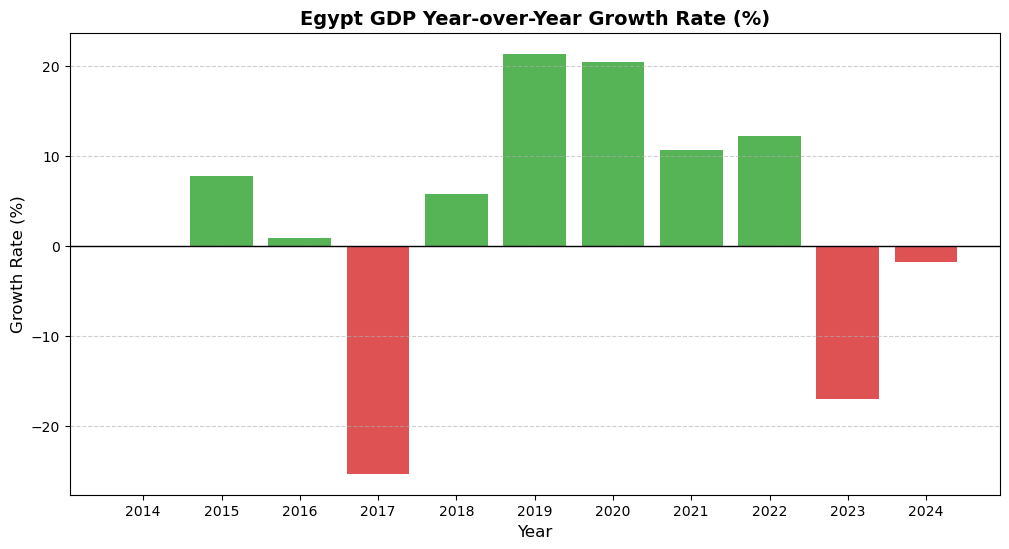

In [10]:
plt.figure(figsize=(12, 6))

# رسم الأعمدة البيانية
colors = ['#d62728' if x < 0 else '#2ca02c' for x in df_final['Growth_Rate'].fillna(0)]
plt.bar(df_final['Year'], df_final['Growth_Rate'].fillna(0), color=colors, alpha=0.8)

# التنسيق
plt.axhline(0, color='black', linewidth=1) # خط الصفر
plt.title('Egypt GDP Year-over-Year Growth Rate (%)', fontsize=14, fontweight='bold')
plt.ylabel('Growth Rate (%)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(df_final['Year'])
plt.show()

# Economic Period Analysis

In [6]:
def professional_insights():
    print("--- Senior Economic Analyst Insights ---\n")
    print("Historical Perspective (2014-2024):")
    print("- The 'Zero-Baseline' view shows that despite two major currency devaluations (2016 & 2022/23),")
    print("  the Egyptian economy has maintained a significantly higher floor than a decade ago.")
    print("- The peak in 2022 (~$477B) demonstrates the massive expansion of the state's footprint.")
    print("- The contraction in 2023-2024 reflects 'Exchange Rate Realism' rather than a loss of productivity,")
    print("  as the nominal value in USD is adjusted to match the market rate of the EGP.")

professional_insights()

--- Senior Economic Analyst Insights ---

Historical Perspective (2014-2024):
- The 'Zero-Baseline' view shows that despite two major currency devaluations (2016 & 2022/23),
  the Egyptian economy has maintained a significantly higher floor than a decade ago.
- The peak in 2022 (~$477B) demonstrates the massive expansion of the state's footprint.
- The contraction in 2023-2024 reflects 'Exchange Rate Realism' rather than a loss of productivity,
  as the nominal value in USD is adjusted to match the market rate of the EGP.
